In [7]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
%matplotlib inline

# Bank Customer Segmentation Analysis - Student Exercise

In this lab, you will implement customer segmentation using K-means clustering. You'll learn how to:
1. Preprocess data for clustering
2. Perform and visualize dimensionality reduction
3. Implement K-means clustering from scratch
4. Evaluate clustering results

Follow the instructions in each section and fill in the code where indicated.

In [8]:
# Load Data and Preprocess
def load_data(filepath):
    pass

#================ FOR PCA Dimensionality reduction =========
# Apply PCA for Dimensionality Reduction
def apply_pca(x, n_components):
    pass

#================ FOR K-Means ===============================
# Find Optimal Clusters for KMeans (Elbow Method)
def find_optimal_clusters(x, max_clusters=10):
    pass

# Perform KMeans Clustering
# Change None to the number of n_clusters value from the elbow method
def perform_kmeans_clustering(x, n_clusters=None):
    pass

#================ FOR Agglomerative ===============================
# Perform Agglomerative Clustering
# Change None to the number of n_clusters value from the elbow method
def perform_agglomerative_clustering(x, n_clusters=None):
    pass

#================FOR Dendrogram===============================
# Get Linkages for Dendrogram
def get_linkages(x):
    pass

# Plot Dendrogram
def plot_dendrogram(linked):
    pass

## 1. Data Loading and Preprocessing

First, complete the data preprocessing function below. You need to:
1. Load the data
2. Handle categorical variables
3. Scale numerical features

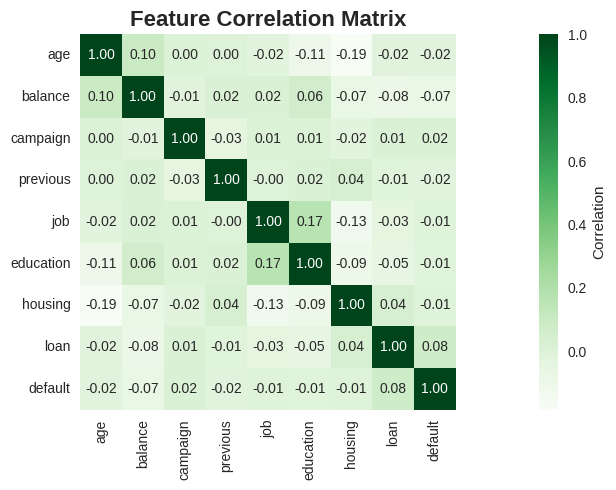

Data shape: (45211, 9)
Number of samples: 45211
Number of features: 9


In [9]:
def load_data(filepath):
    """Load and preprocess the bank marketing dataset.

    TODO:
    1. Load the CSV file (hint: it uses semicolon separator)
    2. Convert categorical columns to numerical using LabelEncoder
    3. Scale the features using StandardScaler
    """
    # Your code here:
    # Load data with semicolon separator
    df = pd.read_csv(filepath, sep=';')

    # List of categorical columns to encode
    categorical_cols = ['job', 'marital', 'education', 'default', 'housing',
                       'loan', 'contact', 'month', 'poutcome', 'y']

    # Apply label encoding to categorical columns
    for col in categorical_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])

    # Select features for clustering
    features = ['age', 'balance', 'campaign', 'previous', 'job', 'education',
                'housing', 'loan', 'default']
    X = df[features]

    plt.figure(figsize=(17, 5))
    correlation_matrix = X.corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='Greens',
                square=True, cbar_kws={'label': 'Correlation'})
    plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, df

# Load and preprocess the data
X_scaled, data = load_data('bank-full.csv')
print("Data shape:", X_scaled.shape)
print("Number of samples:", X_scaled.shape[0])
print("Number of features:", X_scaled.shape[1])


In [10]:
class KMeansClustering:
    """Minimal K-means skeleton for students to implement.

    Students should implement the core methods below:
    - _initialize_centroids
    - _assign_clusters
    - _update_centroids
    - fit

    Keep implementations simple and readable; tests and visualization code will
    use these methods once implemented.
    """
    def __init__(self, n_clusters=3, max_iters=100, random_state=42):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None
        self.labels = None

    def _initialize_centroids(self, X):
        """Initialize centroids.

        TODO (student):
        - Randomly select `n_clusters` distinct points from X as initial centroids.
        - Return an array of shape (n_clusters, n_features).
        Hint: Use np.random.choice to pick indices.
        """
        np.random.seed(self.random_state)
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, self.n_clusters, replace=False)
        self.centroids = X[indices].copy()
        return self.centroids

    def _assign_clusters(self, X):
        """Assign each sample in X to the nearest centroid.

        TODO (student):
        - Compute distance from each point to each centroid (Euclidean)
        - Return an integer array of shape (n_samples,) with cluster labels
        Hint: np.linalg.norm with axis manipulation or broadcasting helps here.
        """
        distances = np.sqrt(((X[:, np.newaxis] - self.centroids) ** 2).sum(axis=2))
        labels = np.argmin(distances, axis=1)
        return labels

    def _update_centroids(self, X, labels):
        """Recompute centroids as the mean of points assigned to each cluster.

        TODO (student):
        - For each cluster id in 0..n_clusters-1 compute the mean of points
        assigned to that cluster. If a cluster has no points, consider reinitializing
        its centroid (or leave unchanged) — discuss in your report.
        - Return an array of shape (n_clusters, n_features).
        """
        new_centroids = np.zeros_like(self.centroids)
        for i in range(self.n_clusters):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                new_centroids[i] = np.mean(cluster_points, axis=0)
            else:
                # If cluster is empty, keep the old centroid
                new_centroids[i] = self.centroids[i]
        return new_centroids

    def fit(self, X):
        """Run K-means until convergence or max_iters.

        TODO (student):
        - Initialize centroids
        - Loop: assign clusters, update centroids
        - Stop early if centroids do not change (or change below a tiny threshold)
        - Store final labels in self.labels and centroids in self.centroids
        - Return self
        """
        self._initialize_centroids(X)

        for iteration in range(self.max_iters):
            # Assign clusters
            self.labels = self._assign_clusters(X)

            # Update centroids
            new_centroids = self._update_centroids(X, self.labels)

            # Check for convergence
            if np.allclose(self.centroids, new_centroids, atol=1e-6):
                print(f"Converged at iteration {iteration + 1}")
                break

            self.centroids = new_centroids

        return self

    def predict(self, X):
        """Assign cluster labels to X using the learned centroids.

        Implementation may call _assign_clusters but should error if centroids
        are not yet initialized (i.e., if fit wasn't called).
        """
        if self.centroids is None:
            raise ValueError("Model has not been fitted yet. Call fit(X) first.")
        return self._assign_clusters(X)


## 2. Dimensionality Reduction

Before clustering, we often reduce the dimensionality of our data for better visualization and performance. Implement PCA below:

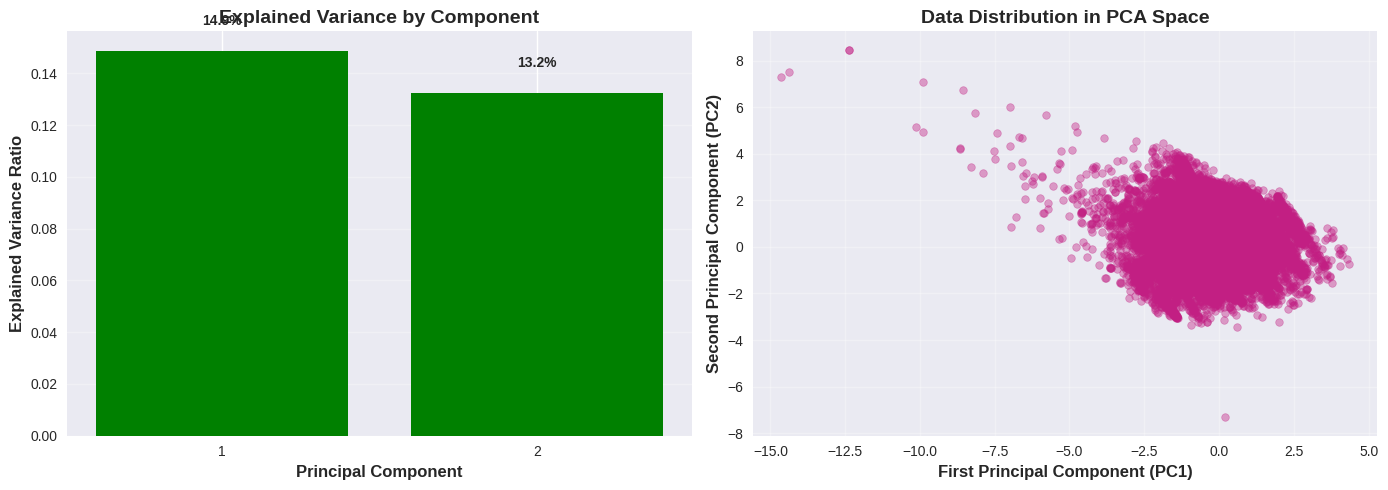

Explained variance ratio: [0.14878447 0.13240902]
Cumulative explained variance: 0.2812

Shape after PCA: (45211, 2)


In [11]:
def apply_pca(X, n_components=2):
    """Apply PCA for dimensionality reduction.

    TODO:
    1. Initialize and fit PCA
    2. Transform the data
    3. Create visualizations to understand:
       - Explained variance ratio
       - Cumulative explained variance
       - Data distribution in 2D
    """
    # Apply PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    components = np.arange(1, n_components + 1)
    axes[0].bar(components, pca.explained_variance_ratio_, color='green', linewidth=1.5)
    axes[0].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Explained Variance Ratio', fontsize=12, fontweight='bold')
    axes[0].set_title('Explained Variance by Component', fontsize=14, fontweight='bold')
    axes[0].set_xticks(components)
    axes[0].grid(axis='y', alpha=0.3)


    for i, v in enumerate(pca.explained_variance_ratio_):
        axes[0].text(i + 1, v + 0.01, f'{v*100:.1f}%', ha='center', fontweight='bold')

    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.4, c='#c21f83', linewidth=0.5, s=30)
    axes[1].set_xlabel('First Principal Component (PC1)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Second Principal Component (PC2)', fontsize=12, fontweight='bold')
    axes[1].set_title('Data Distribution in PCA Space', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
    print(f"Cumulative explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")

    return X_pca

# Apply PCA
X_pca = apply_pca(X_scaled)
print("\nShape after PCA:", X_pca.shape)


## 3. Clustering Evaluation

Implement functions to evaluate the quality of your clustering results:

Computing elbow curve...
Converged at iteration 32
k=2: Inertia=75892.03, Silhouette=0.3311
Converged at iteration 27
k=3: Inertia=48179.64, Silhouette=0.3867
Converged at iteration 25
k=4: Inertia=38059.02, Silhouette=0.3581
Converged at iteration 34
k=5: Inertia=31800.29, Silhouette=0.3494
Converged at iteration 24
k=6: Inertia=27188.82, Silhouette=0.3669
Converged at iteration 99
k=7: Inertia=23384.33, Silhouette=0.3719
Converged at iteration 35
k=8: Inertia=20709.54, Silhouette=0.3751
Converged at iteration 70
k=9: Inertia=19113.00, Silhouette=0.3689
Converged at iteration 69
k=10: Inertia=17985.76, Silhouette=0.3445


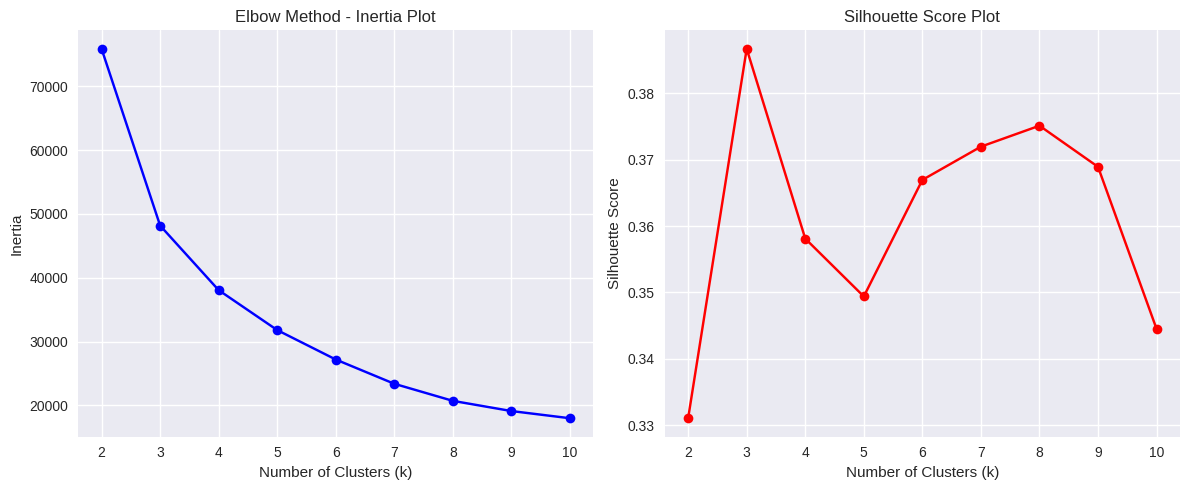

Converged at iteration 27
Final centroids:
 [[ 1.16180335  0.4027139 ]
 [-1.04902366  1.09281623]
 [-0.35551135 -0.92038007]]

Final Clustering Metrics:
Inertia: 48179.64
Silhouette Score: 0.387

Cluster Sizes:
  Cluster 0: 15411 samples
  Cluster 1: 10541 samples
  Cluster 2: 19259 samples


/tmp/ipython-input-2182398254.py:121: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax3.boxplot(silhouette_data, labels=[f'Cluster {i}' for i in unique])


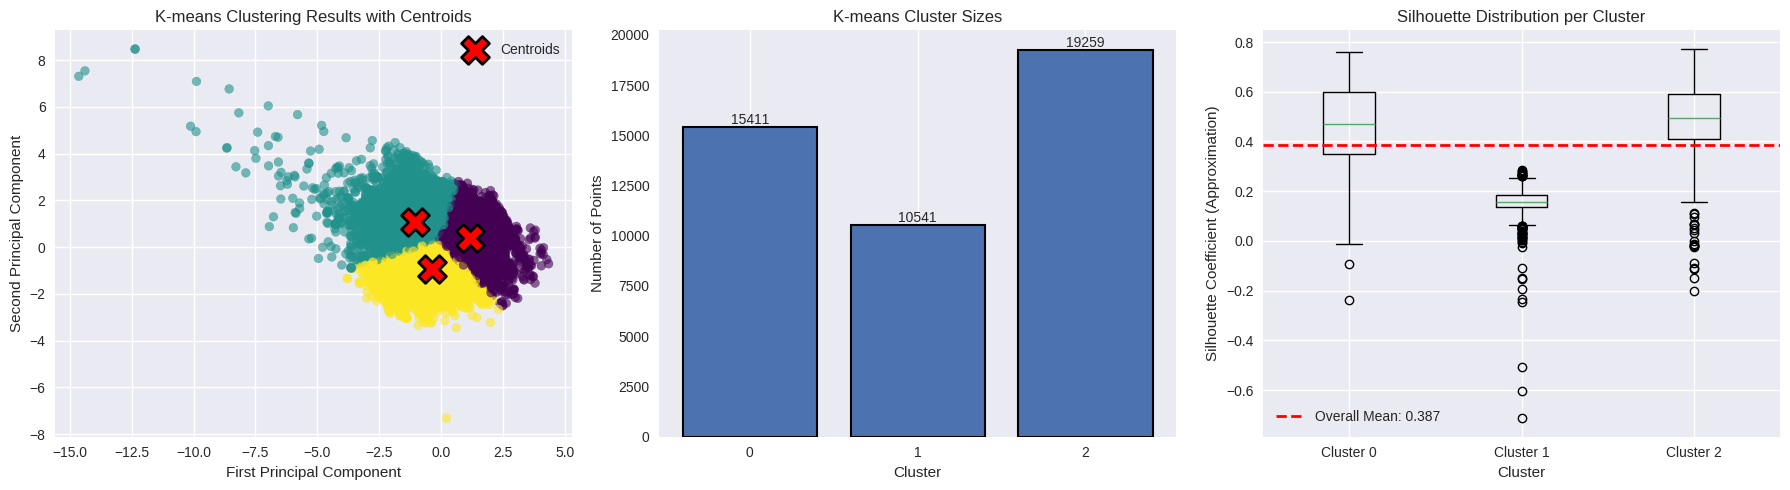


All plots generated successfully!


In [12]:
def calculate_inertia(X, labels, centroids):
    """Calculate the within-cluster sum of squares (inertia)."""
    inertia = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            distances = np.linalg.norm(cluster_points - centroids[i], axis=1)
            inertia += np.sum(distances ** 2)
    return inertia

def plot_elbow_curve(X, max_k=10):
    """Plot the elbow curve to find optimal number of clusters."""
    inertias = []
    silhouette_scores = []
    K = range(2, max_k + 1)

    print("Computing elbow curve...")
    for k in K:
        kmeans = KMeansClustering(n_clusters=k)
        kmeans.fit(X)
        inertia = calculate_inertia(X, kmeans.labels, kmeans.centroids)
        inertias.append(inertia)
        sil_score = silhouette_score(X, kmeans.labels)
        silhouette_scores.append(sil_score)
        print(f"k={k}: Inertia={inertia:.2f}, Silhouette={sil_score:.4f}")

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(K, inertias, 'bo-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Inertia')
    plt.title('Elbow Method - Inertia Plot')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(K, silhouette_scores, 'ro-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score Plot')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return inertias, silhouette_scores

# Run elbow curve analysis
inertias, silhouette_scores = plot_elbow_curve(X_pca, max_k=10)

# Apply final clustering
kmeans = KMeansClustering(n_clusters=3)
kmeans.fit(X_pca)
print("Final centroids:\n", kmeans.centroids)

# Calculate final metrics
final_inertia = calculate_inertia(X_pca, kmeans.labels, kmeans.centroids)
final_silhouette = silhouette_score(X_pca, kmeans.labels)

print(f"\nFinal Clustering Metrics:")
print(f"Inertia: {final_inertia:.2f}")
print(f"Silhouette Score: {final_silhouette:.3f}")

# Get cluster information
unique, counts = np.unique(kmeans.labels, return_counts=True)
print(f"\nCluster Sizes:")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples")

fig = plt.figure(figsize=(18, 5))

# Plot 1: K-means Clustering Results with Centroids Visible
ax1 = plt.subplot(1, 3, 1)
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels, cmap='viridis', alpha=0.6, s=40)
ax1.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
           c='red', marker='X', s=400, edgecolors='black', linewidth=2,
           label='Centroids', zorder=10)
ax1.set_xlabel('First Principal Component')
ax1.set_ylabel('Second Principal Component')
ax1.set_title('K-means Clustering Results with Centroids')
ax1.legend()
ax1.grid(True)

# Plot 2: K-means Cluster Sizes (Bar Plot)
ax2 = plt.subplot(1, 3, 2)
ax2.bar(unique, counts, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('Cluster')
ax2.set_ylabel('Number of Points')
ax2.set_title('K-means Cluster Sizes')
ax2.set_xticks(unique)
ax2.grid(axis='y')

# Add count labels on bars
for cluster, count in zip(unique, counts):
    ax2.text(cluster, count, f'{count}', ha='center', va='bottom')

ax3 = plt.subplot(1, 3, 3)

silhouette_data = []
for cluster in unique:
    cluster_mask = kmeans.labels == cluster
    cluster_points = X_pca[cluster_mask]

    # Calculate average distance within cluster
    within_dist = []
    for point in cluster_points[:500]:
        dist_to_centroid = np.linalg.norm(point - kmeans.centroids[cluster])
        within_dist.append(dist_to_centroid)

    if len(within_dist) > 0:
        within_dist = np.array(within_dist)

        other_centroids_dist = [np.linalg.norm(kmeans.centroids[cluster] - kmeans.centroids[other])
                               for other in unique if other != cluster]
        nearest_cluster_dist = min(other_centroids_dist) if other_centroids_dist else 1
        approx_silhouette = (nearest_cluster_dist - within_dist) / max(nearest_cluster_dist, within_dist.max())
        silhouette_data.append(approx_silhouette)
    else:
        silhouette_data.append([0])

bp = ax3.boxplot(silhouette_data, labels=[f'Cluster {i}' for i in unique])
ax3.axhline(y=final_silhouette, color='red', linestyle='--', linewidth=2,
           label=f'Overall Mean: {final_silhouette:.3f}')
ax3.set_xlabel('Cluster')
ax3.set_ylabel('Silhouette Coefficient (Approximation)')
ax3.set_title('Silhouette Distribution per Cluster')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

print("\nAll plots generated successfully!")


## 4. Recursive Bisecting K-means (Student exercise)

This is an optional exercise for students who want to explore a hierarchical variant of K-means.

Task: implement a concise bisecting K-means procedure that recursively splits clusters into two until a target number of clusters is reached.

Learning goals:
- Understand how repeated binary splits can form a hierarchical clustering
- Practice applying K-means on subclusters and tracking labels/centroids

Hints:
- You can use sklearn's KMeans(k=2) for the binary split step, or reuse your `KMeansClustering` implementation.
- Keep label bookkeeping simple: use increasing integer labels for new clusters.
- Store split metadata (parent -> left/right) to enable a tree visualization later.


BONUS: Recursive Bisecting K-means

Bisecting K-means Progress:
Starting with 1 cluster (n_samples=45211)

Iteration 1: Splitting cluster 0 (size=45211)
  → Created cluster 1
  → Cluster 0: 20434 samples
  → Cluster 1: 24777 samples

Iteration 2: Splitting cluster 1 (size=24777)
  → Created cluster 2
  → Cluster 1: 16348 samples
  → Cluster 2: 8429 samples

Completed! Total clusters: 3

COMPARISON: Standard K-means vs Bisecting K-means
Standard K-means Silhouette Score:   0.387
Bisecting K-means Silhouette Score:  0.338
Difference:                           0.049

Bisecting K-means Cluster Sizes:
  Cluster 0: 20434 samples (45.2%)
  Cluster 1: 16348 samples (36.2%)
  Cluster 2: 8429 samples (18.6%)


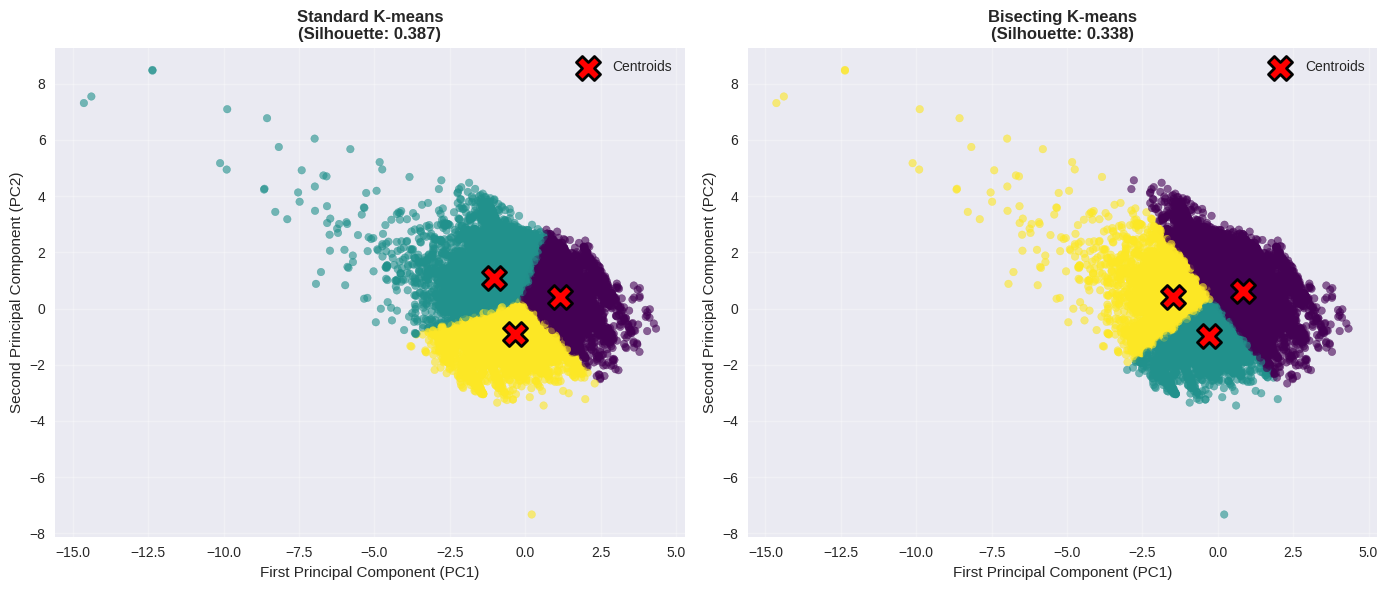


Split Tree (parent → (left_child, right_child)):
  Cluster 0 → (Cluster 0, Cluster 1)
  Cluster 1 → (Cluster 1, Cluster 2)


In [13]:
class BisectingKMeans:
    """Concise skeleton for students to implement a bisecting K-means algorithm.

    Students should implement `fit_predict` to recursively split clusters until
    `n_clusters` is reached.
    """
    def __init__(self, n_clusters, random_state=42):
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.labels_ = None
        # Optional: store mapping parent -> (left_label, right_label)
        self.split_tree = {}
        # Optional: store centroids per cluster id
        self.centers_ = {}

    def fit_predict(self, X):
        """Recursively bisect clusters until `n_clusters` is reached.

        TODO (student):
        - Start with all points assigned to label 0.
        - While number of unique labels < n_clusters:
          - Select a cluster to split (e.g., the largest cluster by size)
          - Run a binary KMeans (k=2) on the points in that cluster
          - Assign new labels (keep one child label as the original, give the other a new id)
          - Record parent -> (left, right) in `self.split_tree` and centroids in `self.centers_`
        - Set and return `self.labels_` (numpy array of length n_samples)

        Hints:
        - Use sklearn.cluster.KMeans(n_clusters=2, random_state=self.random_state) for the split step
        - Keep a counter for new label ids and increment when creating a new cluster
        - Use boolean indexing to operate on subsets of X efficiently
        """
        # Your code here:
        from sklearn.cluster import KMeans

        n_samples = X.shape[0]
        # Start with all points in cluster 0
        self.labels_ = np.zeros(n_samples, dtype=int)
        current_labels = [0]
        next_label = 1

        # Initialize with whole dataset centroid
        self.centers_[0] = np.mean(X, axis=0)

        print("Bisecting K-means Progress:")
        print(f"Starting with 1 cluster (n_samples={n_samples})")

        # Keep splitting until we reach n_clusters
        while len(current_labels) < self.n_clusters:
            # Find the largest cluster to split
            cluster_sizes = {}
            for label in current_labels:
                cluster_sizes[label] = np.sum(self.labels_ == label)

            cluster_to_split = max(cluster_sizes, key=cluster_sizes.get)

            print(f"\nIteration {len(current_labels)}: Splitting cluster {cluster_to_split} (size={cluster_sizes[cluster_to_split]})")

            # Get points in the cluster to split
            mask = self.labels_ == cluster_to_split
            X_cluster = X[mask]

            # Apply binary K-means (k=2) to split the cluster
            kmeans_split = KMeans(n_clusters=2, random_state=self.random_state, n_init=10)
            split_labels = kmeans_split.fit_predict(X_cluster)

            # Update labels: keep one part as original label, assign new label to other part
            # Points with split_labels==0 stay with cluster_to_split
            # Points with split_labels==1 get next_label
            new_mask = mask.copy()
            temp_indices = np.where(mask)[0]
            points_to_relabel = temp_indices[split_labels == 1]
            self.labels_[points_to_relabel] = next_label

            # Record split information
            self.split_tree[cluster_to_split] = (cluster_to_split, next_label)
            self.centers_[cluster_to_split] = kmeans_split.cluster_centers_[0]
            self.centers_[next_label] = kmeans_split.cluster_centers_[1]

            # Update tracking
            current_labels.append(next_label)

            print(f"  → Created cluster {next_label}")
            print(f"  → Cluster {cluster_to_split}: {np.sum(self.labels_ == cluster_to_split)} samples")
            print(f"  → Cluster {next_label}: {np.sum(self.labels_ == next_label)} samples")

            next_label += 1

        print(f"\nCompleted! Total clusters: {len(current_labels)}")
        return self.labels_

# Apply Bisecting K-means with k=3 to compare with standard K-means
print("\n" + "="*70)
print("BONUS: Recursive Bisecting K-means")
print("="*70 + "\n")

bisect = BisectingKMeans(n_clusters=3, random_state=42)
labels_bisect = bisect.fit_predict(X_pca)

# Calculate silhouette score for comparison
silhouette_bisect = silhouette_score(X_pca, labels_bisect)

print(f"\n{'='*70}")
print("COMPARISON: Standard K-means vs Bisecting K-means")
print("="*70)
print(f"Standard K-means Silhouette Score:   {final_silhouette:.3f}")
print(f"Bisecting K-means Silhouette Score:  {silhouette_bisect:.3f}")
print(f"Difference:                           {abs(silhouette_bisect - final_silhouette):.3f}")
print("="*70)

# Get cluster sizes for Bisecting K-means
unique_bisect, counts_bisect = np.unique(labels_bisect, return_counts=True)
print(f"\nBisecting K-means Cluster Sizes:")
for cluster, count in zip(unique_bisect, counts_bisect):
    print(f"  Cluster {cluster}: {count} samples ({count/len(labels_bisect)*100:.1f}%)")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Standard K-means
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels, cmap='viridis', alpha=0.6, s=30)
axes[0].scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
               c='red', marker='X', s=300, edgecolors='black', linewidth=2, label='Centroids')
axes[0].set_xlabel('First Principal Component (PC1)')
axes[0].set_ylabel('Second Principal Component (PC2)')
axes[0].set_title(f'Standard K-means\n(Silhouette: {final_silhouette:.3f})', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bisecting K-means
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_bisect, cmap='viridis', alpha=0.6, s=30)

for cluster_id, centroid in bisect.centers_.items():
    axes[1].scatter(centroid[0], centroid[1], c='red', marker='X', s=300,
                   edgecolors='black', linewidth=2)
axes[1].scatter([], [], c='red', marker='X', s=300, edgecolors='black',
               linewidth=2, label='Centroids')  # For legend
axes[1].set_xlabel('First Principal Component (PC1)')
axes[1].set_ylabel('Second Principal Component (PC2)')
axes[1].set_title(f'Bisecting K-means\n(Silhouette: {silhouette_bisect:.3f})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSplit Tree (parent → (left_child, right_child)):")
for parent, (left, right) in bisect.split_tree.items():
    print(f"  Cluster {parent} → (Cluster {left}, Cluster {right})")


## Bonus Challenges

If you've completed the main tasks, try these extensions:

1. Implement k-means++ initialization
   - Instead of random initialization, use the k-means++ algorithm
   - This should give better and more consistent results

2. Add cluster interpretation
   - Analyze the characteristics of each cluster
   - What features distinguish one cluster from another?
   - Create visualizations to show cluster properties

3. Try different distance metrics
   - Implement Manhattan distance instead of Euclidean
   - Compare the clustering results

4. Add outlier detection
   - Identify points far from all centroids
   - How might you handle these outliers?

Remember to document your code and explain your findings!